# Yellow Taxi EDA

This notebook reads the exported analytical outputs produced by `aggregate_yellow_taxi.py` and focuses on two areas:
- curated-data quality after cleaning
- hourly demand patterns that support the forecasting goal


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "output").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPORT_BASE = PROJECT_ROOT / "output" / "eda" / "yellow"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
EXPORT_BASE


PosixPath('/Users/jimhe/Documents/sjsu/DATA228/Data228GroupProject/output/eda/yellow')

## Load exported datasets

Each dataset is written as a Spark CSV folder with a single `part-*.csv` file. If one of these is missing, rerun the aggregation Spark job first.


In [2]:
def load_export(dataset_name: str) -> pd.DataFrame:
    export_dir = EXPORT_BASE / dataset_name
    part_files = sorted(export_dir.glob("part-*.csv"))
    if not part_files:
        raise FileNotFoundError(
            f"No part file found for {dataset_name} under {export_dir}. "
            "Rerun jobs/aggregate_yellow_taxi.py first."
        )
    return pd.read_csv(part_files[0])


def normalize_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().map({"true": True, "false": False})


curated_profile = load_export("curated_feature_profile")
cleaning_summary = load_export("cleaning_summary")
overall_hourly = load_export("overall_hourly_demand")
borough_hourly = load_export("borough_hourly_demand")
hourly_zone = load_export("hourly_zone_demand")
weekday_weekend = load_export("weekday_weekend_demand")
weekday_hourly = load_export("weekday_hourly_demand")
trip_metrics = load_export("trip_metrics_by_hour")
zone_variability = load_export("zone_demand_variability")
top_pickup = load_export("top_pickup_zones")
top_dropoff = load_export("top_dropoff_zones")

overall_hourly["pickup_hour_ts"] = pd.to_datetime(overall_hourly["pickup_hour_ts"])
borough_hourly["pickup_hour_ts"] = pd.to_datetime(borough_hourly["pickup_hour_ts"])
hourly_zone["pickup_hour_ts"] = pd.to_datetime(hourly_zone["pickup_hour_ts"])
hourly_zone["pickup_hour"] = pd.to_numeric(hourly_zone["pickup_hour"], errors="coerce")
hourly_zone["trip_count"] = pd.to_numeric(hourly_zone["trip_count"], errors="coerce")
hourly_zone["location_id"] = pd.to_numeric(hourly_zone["location_id"], errors="coerce")

weekday_weekend["is_weekend"] = normalize_bool(weekday_weekend["is_weekend"])
weekday_hourly["is_weekend"] = normalize_bool(weekday_hourly["is_weekend"])

for column in [
    "mean_hourly_demand",
    "std_hourly_demand",
    "min_hourly_demand",
    "max_hourly_demand",
    "median_hourly_demand",
    "coefficient_of_variation",
]:
    zone_variability[column] = pd.to_numeric(zone_variability[column], errors="coerce")

{
    "curated_profile": curated_profile.shape,
    "cleaning_summary": cleaning_summary.shape,
    "overall_hourly": overall_hourly.shape,
    "borough_hourly": borough_hourly.shape,
    "hourly_zone": hourly_zone.shape,
    "weekday_weekend": weekday_weekend.shape,
    "weekday_hourly": weekday_hourly.shape,
    "trip_metrics": trip_metrics.shape,
    "zone_variability": zone_variability.shape,
    "top_pickup": top_pickup.shape,
    "top_dropoff": top_dropoff.shape,
}


{'curated_profile': (31, 7),
 'cleaning_summary': (4, 2),
 'overall_hourly': (744, 7),
 'borough_hourly': (4739, 8),
 'hourly_zone': (71465, 13),
 'weekday_weekend': (48, 3),
 'weekday_hourly': (168, 4),
 'trip_metrics': (24, 6),
 'zone_variability': (257, 11),
 'top_pickup': (20, 5),
 'top_dropoff': (20, 5)}

## Cleaning impact and curated feature quality

These tables summarize how many rows were removed during cleaning and how much missing data remains in the curated layer used for all downstream analysis.


In [3]:
cleaning_summary['value'] = cleaning_summary['value'].astype(int)
display(cleaning_summary)
display(curated_profile.sort_values(["null_count", "feature_name"], ascending=[False, True]).head(15))


,metric,value
0,raw_row_count,3066766
1,curated_row_count,3040551
2,removed_row_count,26215
3,removed_pct,0


,approx_distinct_count,data_type,feature_name,non_null_count,null_count,null_pct,row_count
0,7,double,RatecodeID,2968882,71669,2.3571,3040551
1,3,double,airport_fee,2968882,71669,2.3571,3040551
2,3,double,congestion_surcharge,2968882,71669,2.3571,3040551
3,10,double,passenger_count,2968882,71669,2.3571,3040551
4,264,bigint,DOLocationID,3040551,0,0.0000,3040551
5,259,bigint,PULocationID,3040551,0,0.0000,3040551
6,2,bigint,VendorID,3040551,0,0.0000,3040551
7,6189,double,base_passenger_fare,3040551,0,0.0000,3040551
8,34,date,dropoff_date,3040551,0,0.0000,3040551
9,1637350,timestamp,dropoff_datetime,3040551,0,0.0000,3040551


## Overall hourly demand

This is the simplest view of the forecasting target: total trip demand by pickup hour.


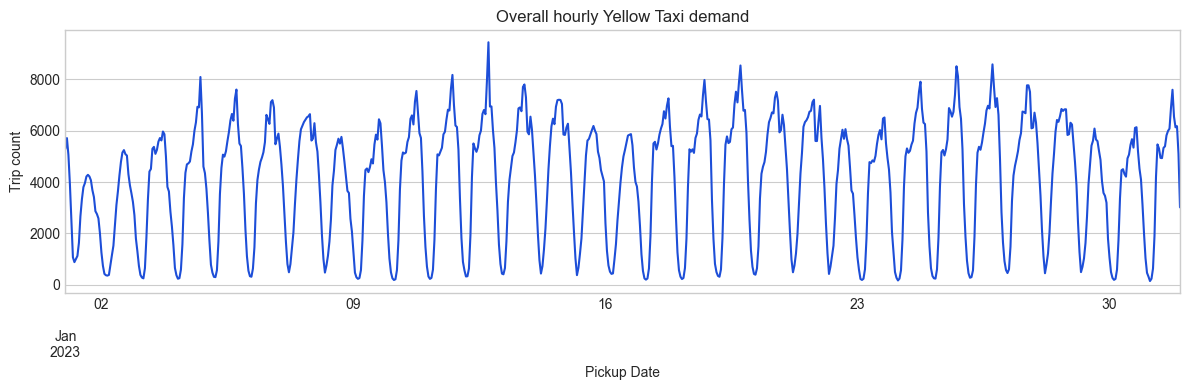

In [4]:
ax = overall_hourly.plot(
    x="pickup_hour_ts",
    y="trip_count",
    figsize=(12, 4),
    title="Overall hourly Yellow Taxi demand",
    legend=False,
    color="#1d4ed8",
)
ax.set_xlabel("Pickup Date")
ax.set_ylabel("Trip count")
plt.tight_layout()


## Borough-level demand over time

This helps show where demand is concentrated and whether different boroughs have distinct hourly behavior.


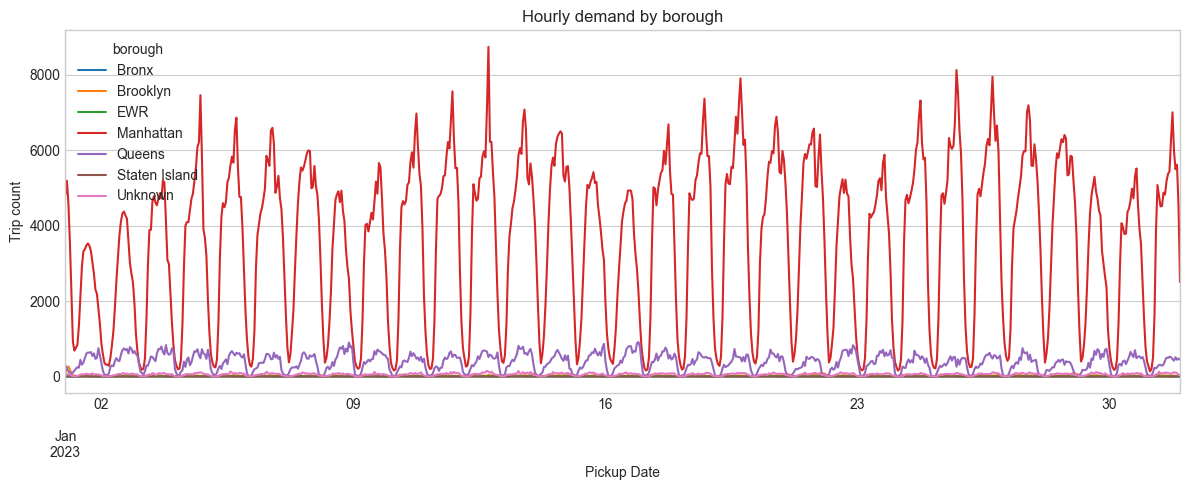

In [5]:
borough_pivot = borough_hourly.pivot_table(
    index="pickup_hour_ts",
    columns="borough",
    values="trip_count",
    aggfunc="sum",
).fillna(0)

ax = borough_pivot.plot(figsize=(12, 5), title="Hourly demand by borough")
ax.set_xlabel("Pickup Date")
ax.set_ylabel("Trip count")
plt.tight_layout()


## Weekday and weekend demand patterns

These views justify time-based features such as hour-of-day and weekend indicators.


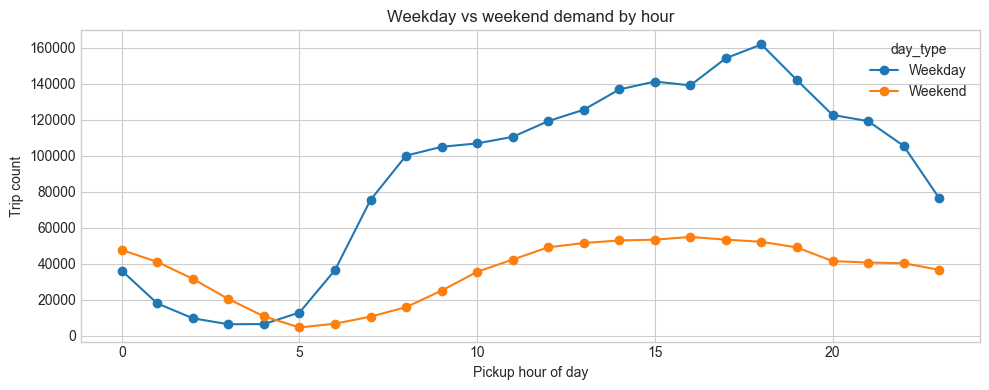

In [6]:
weekday_weekend["day_type"] = weekday_weekend["is_weekend"].map({True: "Weekend", False: "Weekday"})
pivot = weekday_weekend.pivot(index="pickup_hour", columns="day_type", values="trip_count")
ax = pivot.plot(figsize=(10, 4), marker="o", title="Weekday vs weekend demand by hour")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Trip count")
plt.tight_layout()


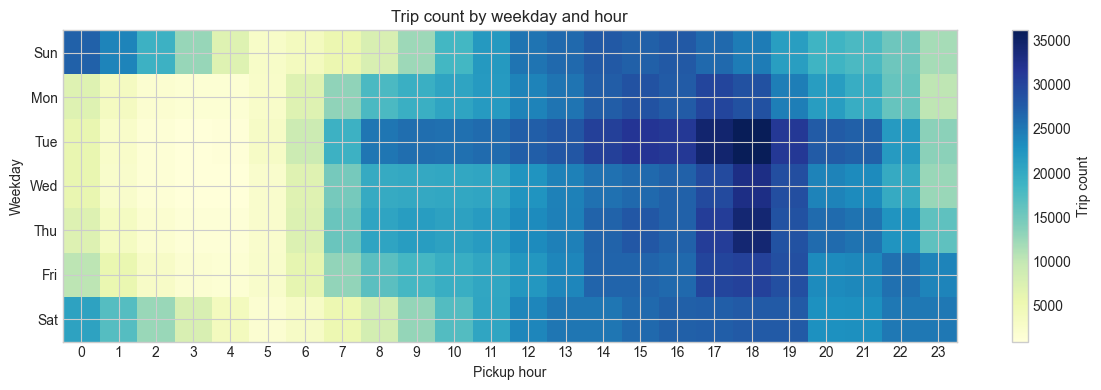

In [7]:
weekday_labels = {
    1: "Sun",
    2: "Mon",
    3: "Tue",
    4: "Wed",
    5: "Thu",
    6: "Fri",
    7: "Sat",
}
weekday_heat = weekday_hourly.pivot_table(
    index="pickup_weekday_num",
    columns="pickup_hour",
    values="trip_count",
    aggfunc="sum",
).sort_index()
weekday_heat.index = [weekday_labels.get(idx, idx) for idx in weekday_heat.index]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(weekday_heat.values, aspect="auto", cmap="YlGnBu")
ax.set_title("Trip count by weekday and hour")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Weekday")
ax.set_xticks(range(len(weekday_heat.columns)))
ax.set_xticklabels(weekday_heat.columns)
ax.set_yticks(range(len(weekday_heat.index)))
ax.set_yticklabels(weekday_heat.index)
fig.colorbar(im, ax=ax, label="Trip count")
plt.tight_layout()


## Demand distribution and variability

These views show how skewed hourly demand is and which zones are the most volatile.


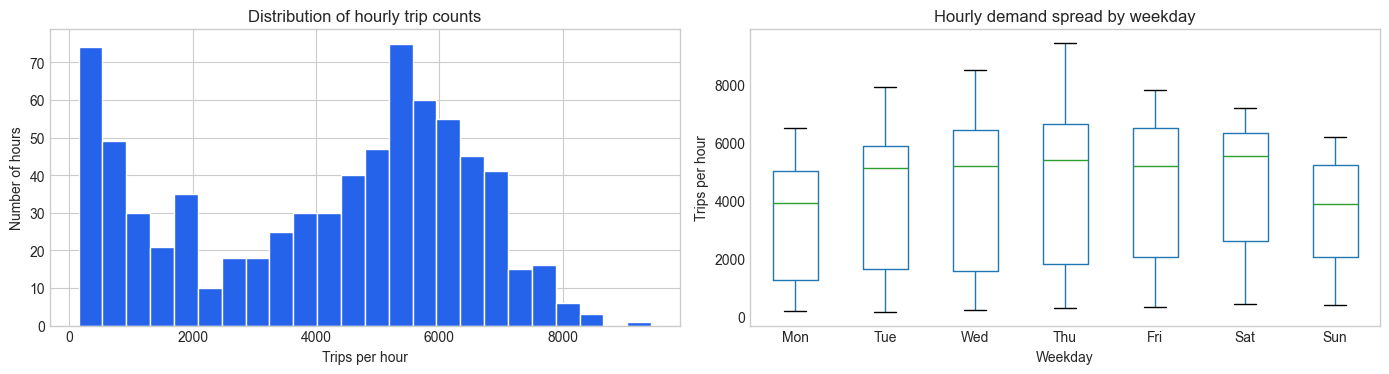

In [8]:
distribution_df = overall_hourly.copy()
distribution_df["weekday_name"] = pd.Categorical(
    distribution_df["pickup_hour_ts"].dt.day_name().str[:3],
    categories=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

distribution_df["trip_count"].plot.hist(
    bins=24,
    ax=axes[0],
    color="#2563eb",
    edgecolor="white",
    title="Distribution of hourly trip counts",
)
axes[0].set_xlabel("Trips per hour")
axes[0].set_ylabel("Number of hours")

distribution_df.boxplot(column="trip_count", by="weekday_name", ax=axes[1], grid=False)
axes[1].set_title("Hourly demand spread by weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Trips per hour")
fig.suptitle("")
plt.tight_layout()


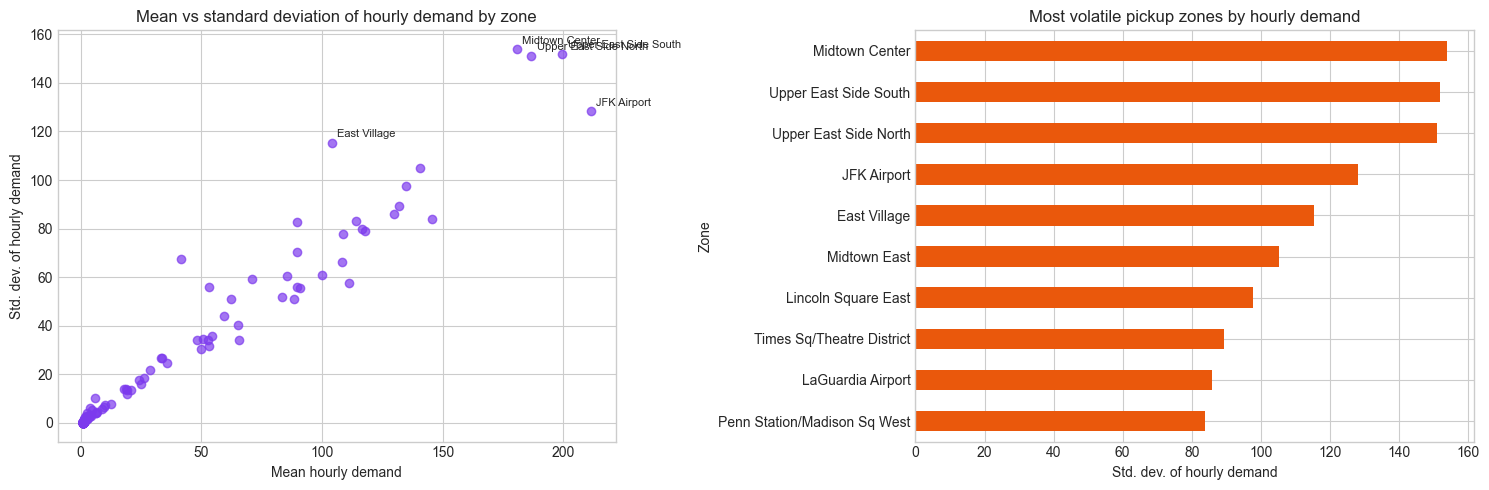

In [9]:
zone_plot = zone_variability.dropna(subset=["mean_hourly_demand", "std_hourly_demand"]).copy()
zone_plot = zone_plot[zone_plot["mean_hourly_demand"] > 0]
zone_plot["zone_label"] = zone_plot["zone"].fillna(zone_plot["location_id"].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(
    zone_plot["mean_hourly_demand"],
    zone_plot["std_hourly_demand"],
    alpha=0.7,
    color="#7c3aed",
)
axes[0].set_title("Mean vs standard deviation of hourly demand by zone")
axes[0].set_xlabel("Mean hourly demand")
axes[0].set_ylabel("Std. dev. of hourly demand")

for _, row in zone_plot.nlargest(5, "std_hourly_demand").iterrows():
    axes[0].annotate(
        row["zone_label"],
        (row["mean_hourly_demand"], row["std_hourly_demand"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

volatile_zones = zone_plot.nlargest(10, "std_hourly_demand").sort_values("std_hourly_demand")
volatile_zones.plot.barh(
    x="zone_label",
    y="std_hourly_demand",
    ax=axes[1],
    legend=False,
    color="#ea580c",
    title="Most volatile pickup zones by hourly demand",
)
axes[1].set_xlabel("Std. dev. of hourly demand")
axes[1].set_ylabel("Zone")
plt.tight_layout()


## Hourly distribution by hour for top pickup zones

Each subplot shows the distribution of `trip_count` at each hour (0-23) for one of the top 5 pickup zones. In a full month, each hour should have about 30-31 samples.


,location_id,zone,min_samples_per_hour,max_samples_per_hour,avg_samples_per_hour
0,132,JFK Airport,31,31,31.00
3,161,Midtown Center,31,31,31.00
4,186,Penn Station/Madison Sq West,31,31,31.00
1,237,Upper East Side South,28,31,30.71
2,236,Upper East Side North,27,31,30.71


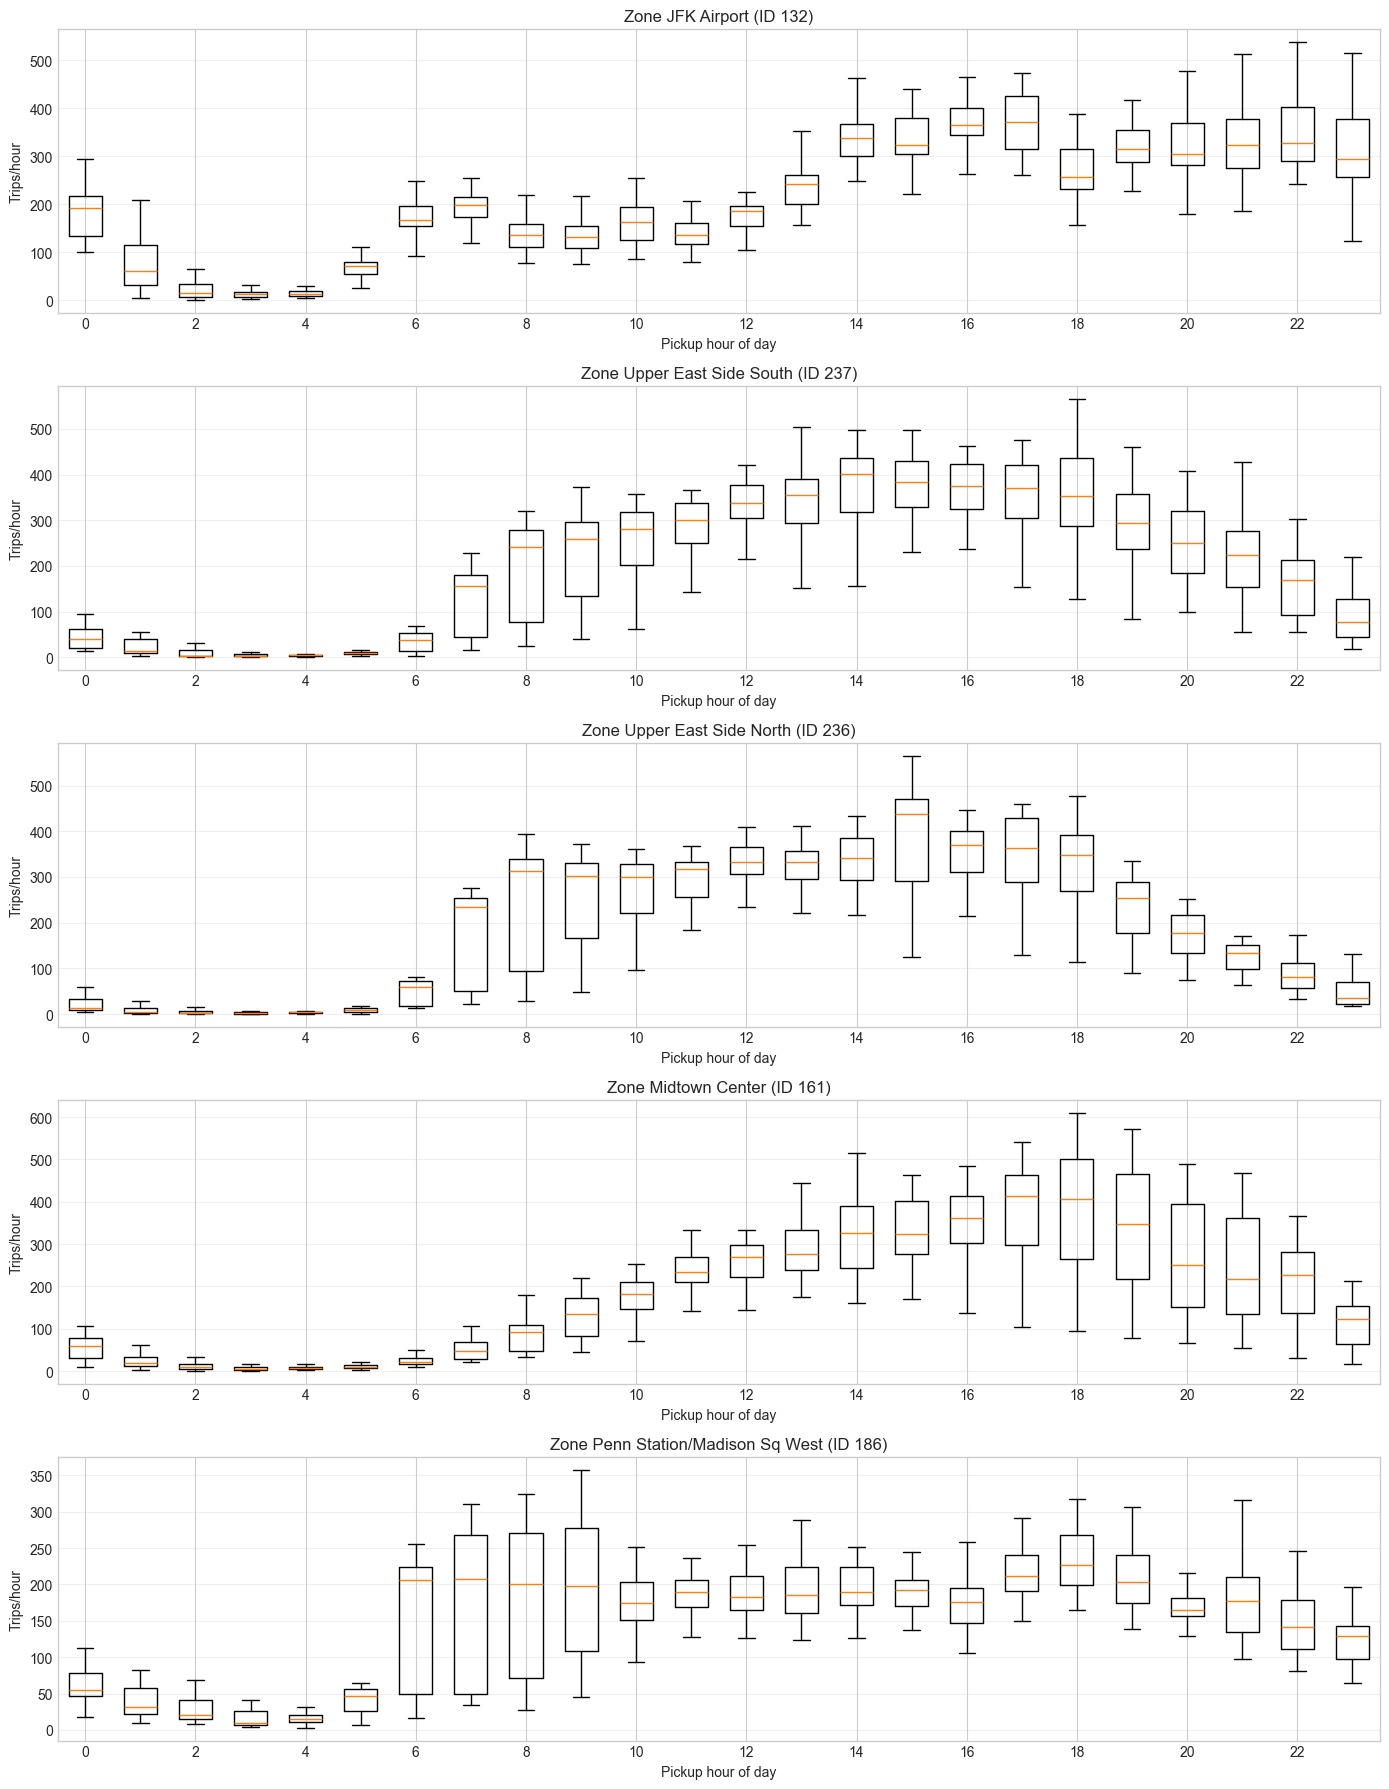

In [10]:
zone_base = hourly_zone.dropna(subset=["location_id", "pickup_hour", "trip_count"]).copy()
zone_base["pickup_hour"] = zone_base["pickup_hour"].astype(int)
zone_base["location_id"] = zone_base["location_id"].astype(int)
zone_base["zone_label"] = zone_base["zone"].fillna(zone_base["location_id"].astype(str))

top5 = (
    zone_base.groupby(["location_id", "zone_label"], as_index=False)["trip_count"]
    .sum()
    .sort_values("trip_count", ascending=False)
    .head(5)
)

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
sample_rows = []

for ax, (_, zone_row) in zip(axes, top5.iterrows()):
    zid = int(zone_row["location_id"])
    zlabel = zone_row["zone_label"]
    zdf = zone_base[zone_base["location_id"] == zid]

    by_hour_values = [
        zdf.loc[zdf["pickup_hour"] == hr, "trip_count"].values
        for hr in range(24)
    ]
    by_hour_counts = [int(len(vals)) for vals in by_hour_values]

    ax.boxplot(by_hour_values, positions=range(24), widths=0.6, showfliers=False)
    ax.set_title(f"Zone {zlabel} (ID {zid})")
    ax.set_xlabel("Pickup hour of day")
    ax.set_ylabel("Trips/hour")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([str(h) for h in range(0, 24, 2)])
    ax.grid(axis="y", alpha=0.3)

    sample_rows.append({
        "location_id": zid,
        "zone": zlabel,
        "min_samples_per_hour": min(by_hour_counts),
        "max_samples_per_hour": max(by_hour_counts),
        "avg_samples_per_hour": round(sum(by_hour_counts) / 24, 2),
    })

plt.tight_layout()

sample_count_summary = pd.DataFrame(sample_rows)
display(sample_count_summary.sort_values("avg_samples_per_hour", ascending=False))


## Top pickup and dropoff zones

These rankings highlight geographic concentration and help motivate zone-level forecasting rather than citywide-only forecasting.


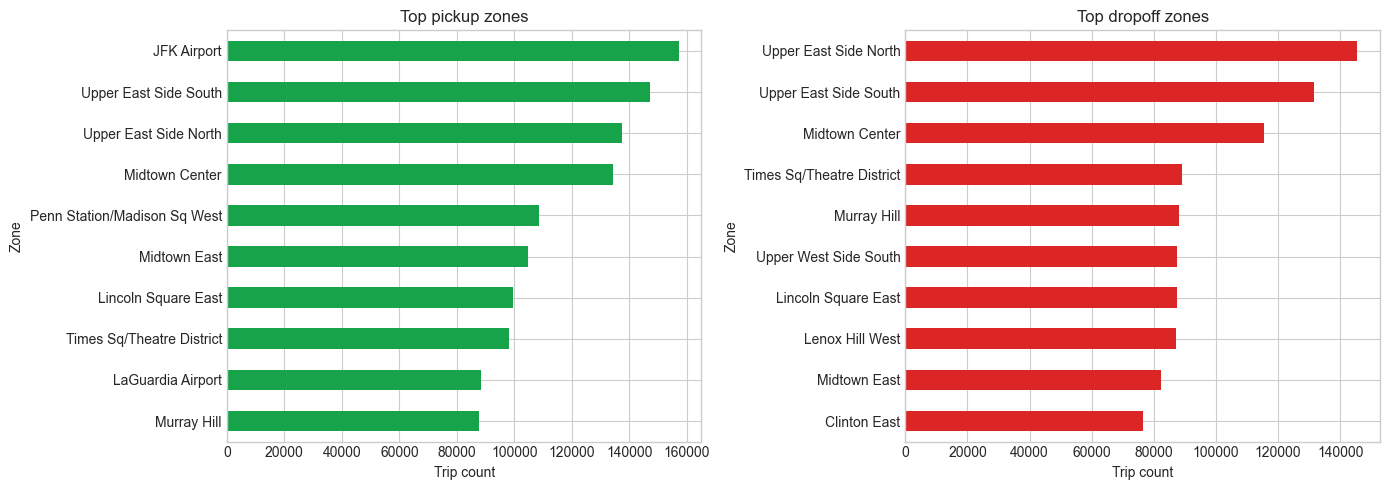

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pickup_plot = top_pickup.head(10).sort_values("trip_count")
pickup_label = "zone" if "zone" in pickup_plot.columns else "location_id"
pickup_plot.plot.barh(
    x=pickup_label,
    y="trip_count",
    ax=axes[0],
    title="Top pickup zones",
    legend=False,
    color="#16a34a",
)
axes[0].set_xlabel("Trip count")
axes[0].set_ylabel("Zone")

dropoff_plot = top_dropoff.head(10).sort_values("trip_count")
dropoff_label = "zone" if "zone" in dropoff_plot.columns else "location_id"
dropoff_plot.plot.barh(
    x=dropoff_label,
    y="trip_count",
    ax=axes[1],
    title="Top dropoff zones",
    legend=False,
    color="#dc2626",
)
axes[1].set_xlabel("Trip count")
axes[1].set_ylabel("Zone")
plt.tight_layout()


## Holiday / Special Day 
This comparison auto-selects an in-scope holiday date so it works for January, December, or mixed-month exports.

In [ ]:
df = overall_hourly.copy()
import datetime as dt

df["pickup_hour_ts"] = pd.to_datetime(df["pickup_hour_ts"])
df["date"] = df["pickup_hour_ts"].dt.date
df["month"] = df["pickup_hour_ts"].dt.month

available_dates = sorted(df["date"].unique())
if not available_dates:
    raise ValueError("No rows found in overall_hourly_demand export.")

# Pick a holiday date that exists in the exported scope.
candidate_holidays = [
    pd.to_datetime("2023-01-01").date(),  # New Year's Day
    pd.to_datetime("2023-12-25").date(),  # Christmas Day
]
date_set = set(available_dates)
holiday_date = next((d for d in candidate_holidays if d in date_set), available_dates[0])

# Use a baseline day about one week later when possible, otherwise nearest non-holiday date.
normal_date = holiday_date + dt.timedelta(days=7)
if normal_date not in date_set:
    non_holiday_dates = [d for d in available_dates if d != holiday_date]
    normal_date = non_holiday_dates[0] if non_holiday_dates else holiday_date

holiday_total = df[df["date"] == holiday_date]["trip_count"].sum()
normal_total = df[df["date"] == normal_date]["trip_count"].sum()

holiday_label = "Holiday" if holiday_date in candidate_holidays else "Selected Day"
normal_label = "Comparison Day"

comparison_df = pd.DataFrame({
    "Day Type": [f"{holiday_label} ({holiday_date})", f"{normal_label} ({normal_date})"],
    "Trip Count": [holiday_total, normal_total]
})

ax = comparison_df.plot(
    kind="bar",
    x="Day Type",
    y="Trip Count",
    legend=False,
    figsize=(8, 4),
    title="Holiday vs Comparison Day Total Demand",
    color="#1d4ed8"
)

ax.set_ylabel("Total Trip Count")
plt.xticks(rotation=0)
plt.tight_layout()